<center>
<a href="http://uf-mi.u-bordeaux.fr/MSS/" ><img src="https://www.math.u-bordeaux.fr/~jbigot/Site/Enseignement_files/logo_MAS_MSS.jpg" style="float:left; max-width: 400px; display: inline" alt="INSA"/></a>

<a href="https://www.math.u-bordeaux.fr/" ><img src="https://www.math.u-bordeaux.fr/~jbigot/Site/Enseignement_files/LogoIMB.jpg" style="float:right; max-width: 250px; display: inline" alt="IMT"/> </a>
</center>

# <a href="https://www.python.org/"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Python_logo_and_wordmark.svg/390px-Python_logo_and_wordmark.svg.png" style="max-width: 200px; display: inline" alt="Python"/></a>  
## **UE M2 Master MAS & CMI ISI : Transport Optimal**

**Projet : Classification Supervisée par Transport Optimal et Calcul des Poids d'un Mélange**  

**Auteurs :** **Fama Diallo**


# Projet : classification supervisée par transport optimal et calcul des poids d'un mélange


## Présentation du projet

Dans ce projet, on se propose d'utiliser la théorie du transport optimal pour classifier un ensemble de données à valeurs dans $\mathbb{R}^d$ avec $d \geq 1$ par une approche supervisée. Cette problématique est motivée par l'analyse de données en cytométrie en flux. Il s'agit d'une biotechnologie à haut débit utilisée pour caractériser une grande quantité de cellules à partir d'un échantillon biologique. La cytométrie en flux est primordiale pour de nombreuses recherches biologiques et immunologiques avec des applications, par exemple, dans la surveillance du système immunitaire des patients atteints du VIH en comptant le nombre de cellules CD4.

La première étape pour caractériser les cellules d'un échantillon biologique par cytométrie en flux consiste à colorer ces cellules. Plus précisément, les cellules sont colorées avec plusieurs anticorps monoclonaux conjugués par fluorescence dirigés contre les marqueurs cellulaires d'intérêt. Ensuite, les cellules circulent une par une à travers le faisceau laser du cytomètre. La lumière diffusée est caractéristique des marqueurs biologiques des cellules. Ainsi, à partir d'un échantillon biologique analysé par un cytomètre en flux, on obtient un jeu de données $Y_1,\ldots,Y_m$ où chaque observation $Y_j$ correspond à une seule cellule traversant le faisceau laser. Pour une observation $Y_j \in \mathbb{R}^d$, la coordonnée $Y_j^{(k)}$ correspond à l'intensité lumineuse émise par l'anticorps fluorescent fixé au marqueur biologique $k$. Fait intéressant, un tel ensemble de données peut également être considéré comme la mesure empirique discrète :

$$
\hat{\nu}_m = \frac{1}{m} \sum_{j=1}^{m} \delta_{Y_j}
$$

et c'est le point de vue choisi dans ce projet.

L'un des enjeux majeurs en cytométrie est d'identifier les différentes populations cellulaires et sous-types présents dans l'échantillon biologique. Pour cela, on se propose d'utiliser une approche supervisée qui utilise la connaissance d'un autre échantillon (dit source) $X_1,\ldots,X_n$ pour lequel la classification en $K$ sous-populations cellulaires $C_1,\ldots,C_K$  est connue. Ceci se traduit par le fait que la mesure empirique
$
\hat{\mu}_n = \frac{1}{n} \sum_{i=1}^{n} \delta_{X_i}
$
se décompose de la façon suivante

$$
\hat{\mu}_n = \sum_{k=1}^K \frac{n_k}{I} \left( \sum_{i: X_i \in C_k} \frac{1}{n_k} \delta_{X_i} \right) = \sum_{k=1}^K \frac{n_k}{n} \hat{\mu}_k,
$$
avec $n_k = \#C_k$ et $\hat{\mu}_k = \sum_{i: X_i \in C_k} \frac{1}{n_k} \delta_{X_i}$ est la mesure empirique des observations qui appartiennent à la sous-population $C_k$ (classe connue).

L'enjeu de ce projet est d'utiliser cette connaissance sur la mesure $\hat{\mu}_n$ (dite source) pour la transporter sur la mesure $\hat{\nu}_m$ (dite cible) et ainsi en déduire la classe d'appartenance de chacun des vecteur $Y_j$ (et donc celle des cellules de l'échantillon non-labellisé). Par ailleurs, cette approche permet également de déterminer la proportion de chaque classe $C_1,\ldots,C_K$  dans l'échantillon $Y_1,\ldots,Y_m$.

Dans ce projet, vous utiliserez des données de cytométrie en flux qui sont en accès libre via le projet HIPC (Human Immunology Project Consortium) : https://www.immuneprofiling.org/hipc/page/show

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Jeu de données source (chaque groupe travaillera sur des données différentes)
Stanford1A_values = pd.read_csv('/content/W2_4_values.csv',
                                 usecols = np.arange(1,8))
Stanford1A_clust = pd.read_csv('/content/W2_4_clust.csv',
                                usecols = [1]) # Vrai clustering des données source

# Jeu de données cible (chaque groupe travaillera sur des données différentes)
# Dans le projet, on supposera que le clustering est inconnu pour ce jeu de données cible
# mais on pourra ensuite se comparer au vrai clustering

Stanford3C_values = pd.read_csv('/content/W2_5_values.csv',
                                 usecols = np.arange(1,8))
Stanford3C_clust = pd.read_csv('/content/W2_5_clust.csv',
                                usecols = [1]) # Vrai clustering des données cible

# Pré-traitement des données
X = np.asarray(Stanford1A_values)
X = X * (X > 0)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_clust = np.asarray(Stanford1A_clust['x'])

Y = np.asarray(Stanford3C_values)
Y = Y * (Y > 0)
scaler = MinMaxScaler()
Y = scaler.fit_transform(Y)
Y_clust = np.asarray(Stanford3C_clust['x'])


K = np.max(X_clust)
print('K =',K)
d = X.shape[1]
print('d =',d)
n = X.shape[0]
print('n =',n)
m = Y.shape[0]
print('m =',m)

K = 10
d = 7
n = 32273
m = 32258


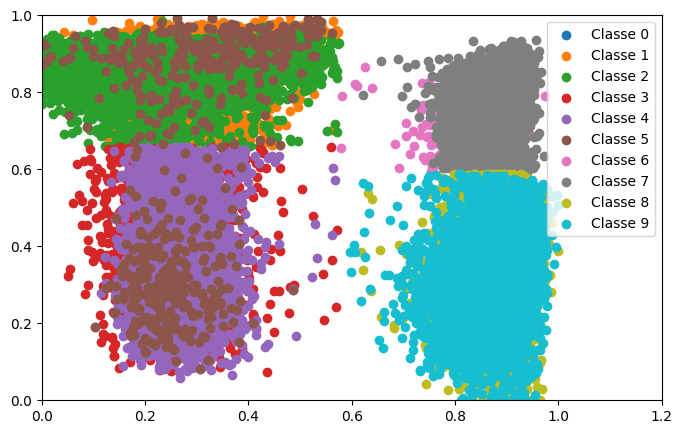

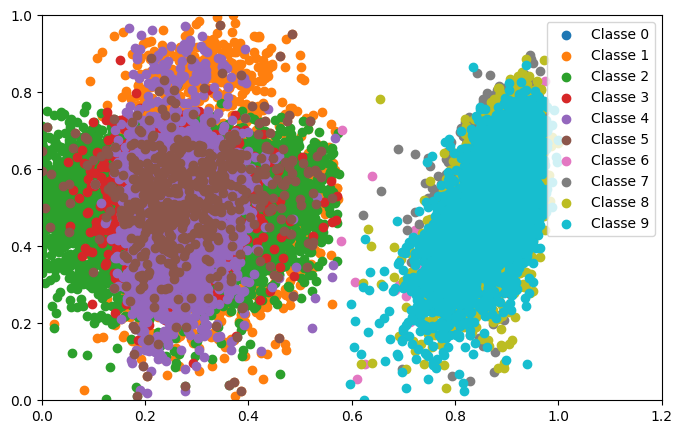

In [ ]:
# Visualisation d'une projection 2D des données source : Marqueur 1 versus Marqueur 2
plt.figure(figsize = (8,5))

for cl in range(K):
    plt.scatter(X[X_clust == cl,1], X[X_clust == cl,2], label = 'Classe {}'.format(cl))
plt.xlim(0,1.2)
plt.ylim(0,1)
plt.legend(loc = 'upper right')

# Visualisation d'une projection 2D des données source : Marqueur 1 versus Marqueur 3
plt.figure(figsize = (8,5))

for cl in range(K):
    plt.scatter(X[X_clust == cl,1], X[X_clust == cl,3], label = 'Classe {}'.format(cl))
plt.legend(loc = 'upper right')
plt.xlim(0,1.2)
plt.ylim(0,1)
plt.legend(loc = 'upper right')

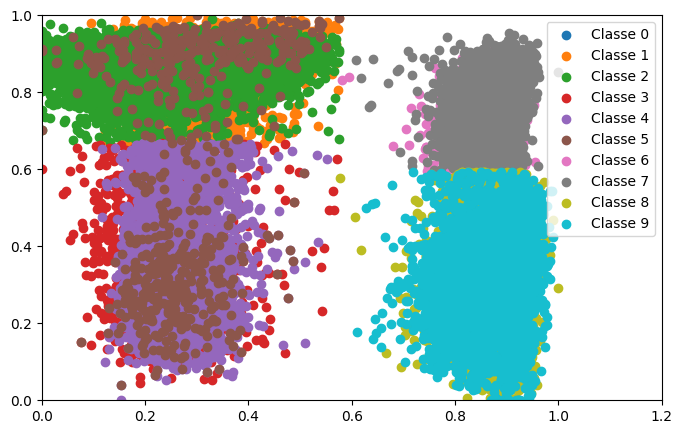

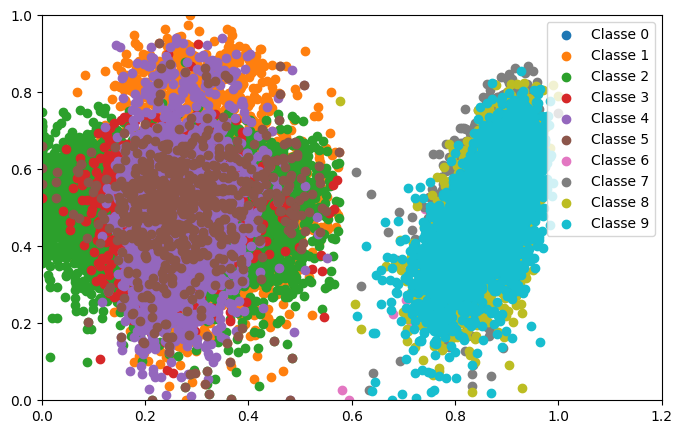

In [ ]:
# Visualisation d'une projection 2D des données cible : Marqueur 1 versus Marqueur 2
plt.figure(figsize = (8,5))

for cl in range(K):
    plt.scatter(Y[Y_clust == cl,1], Y[Y_clust == cl,2], label = 'Classe {}'.format(cl))
plt.xlim(0,1.2)
plt.ylim(0,1)
plt.legend(loc = 'upper right')

# Visualisation d'une projection 2D des données source : Marqueur 1 versus Marqueur 3
plt.figure(figsize = (8,5))

for cl in range(K):
    plt.scatter(Y[Y_clust == cl,1], Y[Y_clust == cl,3], label = 'Classe {}'.format(cl))
plt.legend(loc = 'upper right')
plt.xlim(0,1.2)
plt.ylim(0,1)
plt.legend(loc = 'upper right')

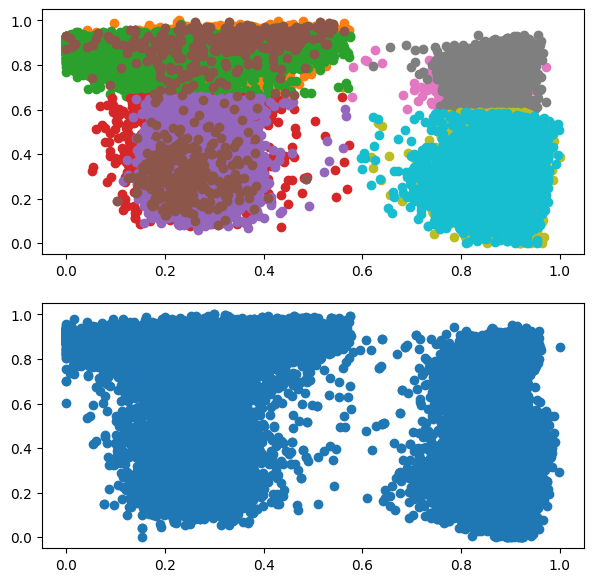

In [ ]:
# Visualisation d'une projection 2D des données cible : Marqueur 1 versus Marqueur 2
# et des données sources sans clustering
plt.figure(figsize = (7,7))
plt.subplot(2,1,1)
for cl in range(K):
    plt.scatter(X[X_clust == cl,1], X[X_clust == cl,2], label = 'Classe {}'.format(cl))

plt.subplot(2,1,2)
plt.scatter(Y[:,1],Y[:,2])

In [ ]:
#pip install pot

In [ ]:
import numpy as np
from sklearn.utils import resample
import pandas as pd
import ot
from sklearn.metrics import accuracy_score, confusion_matrix
from IPython.display import display, Math, Latex
from scipy.spatial.distance import cdist
from collections import Counter
import time

## **Définition du problème**

Dans ce projet, nous abordons la classification supervisée des données cibles à l'aide de la théorie du transport optimal. L'objectif principal est de transférer les informations structurelles de la distribution source, dont les classes sont connues, vers la distribution cible, pour laquelle les classes sont inconnues.

Soient :

$(\hat{\mu}n = \frac{1}{n} \sum{i=1}^{n} \delta_{X_i})$, la mesure empirique source, où chaque observation $(X_i \in \mathbb{R}^d)$ est associée à une classe connue.
$(\hat{\nu}m = \frac{1}{m} \sum{j=1}^{m} \delta_{Y_j})$, la mesure empirique cible, où chaque observation $(Y_j \in \mathbb{R}^d)$ est à classifier.

L'objectif est de transporter la mesure source vers la mesure cible en minimisant le coût total de transport, tout en respectant les contraintes de conservation de masse.

## **Matrice de Coût pour l'ensemble du Projet**

La matrice de coût $C$ est définie comme suit :

$C_{ij} = \log(1 + | X_i - Y_j |^2)$
où :

$| X_i - Y_j |^2$ représente la distance euclidienne au carré entre $X_i$ et $Y_j$.
La transformation logarithmique réduit l'influence des paires ayant de très grandes distances, ce qui améliore la stabilité numérique du calcul du plan de transport optimal.

## **Partie I : Problème primal avec programmation linéaire via ot.emd**

Le problème primal peut être écrit comme suit :  
$$
P^* = \underset{P \in \mathcal{U}(\hat{\mu}_n, \hat{\nu}_m)}{\text{argmin}} \; \sum_{i=1}^{n} \sum_{j=1}^{m} C_{ij} P_{ij},
$$

sous les contraintes :
1. Les marges respectent les masses sources :  
   $$
   \sum_{j=1}^{m} P_{ij} = a_i, \; \forall i = 1, \ldots, n.
   $$
2. Les marges respectent les masses cibles :  
   $$
   \sum_{i=1}^{n} P_{ij} = b_j, \; \forall j = 1, \ldots, m.
   $$
3. Les quantités transportées sont non négatives :  
   $$
   P_{ij} \geq 0, \; \forall i, j.
   $$

Le plan de transport optimal $P^*$ minimise ainsi le coût total sous ces trois contraintes.

Résolution avec l’algorithme primal
L'algorithme primal utilise des méthodes de programmation linéaire pour résoudre le problème de transport optimal. Grâce à la bibliothèque ot, la fonction ot.emd permet de calculer directement le plan de transport optimal $P^*$.

Étapes de la Résolution
1. Construction des vecteurs de masse
Les masses sont supposées uniformément réparties sur les distributions source et cible :

$a_i = \frac{1}{n}, ; \forall i$
$b_j = \frac{1}{m}, ; \forall j$
2. Calcul de la Matrice de Coût
La matrice $C$ est construite à partir des distances euclidiennes au carré, puis stabilisée par une transformation logarithmique :

$C_{ij} = \log(1 + | X_i - Y_j |^2)$
3. Résolution du problème primal
La résolution est effectuée via la fonction ot.emd, qui minimise directement le coût total du transport :

$P^* = \underset{P \in \mathcal{U}(\hat{\mu}n, \hat{\nu}m)}{\text{argmin}} ; \sum{i=1}^{n} \sum{j=1}^{m} C_{ij} P_{ij}$
4. Analyse du Plan de Transport
À partir du plan de transport optimal $P^*$, plusieurs quantités peuvent être extraites :

Masse totale transportée :
$\text{Masse transportée} = \sum_{i=1}^{n} \sum_{j=1}^{m} P^*_{ij}$

La masse totale transportée permet également de vérifier la bonne convergence de l'algorithme :

- Si l'algorithme a convergé correctement, alors Masse transportée $\approx 1$.

### **Calcul du plan de transport optimal**

In [ ]:
C = cdist(X, Y, metric='sqeuclidean')
C = np.log1p(C)  # log(1 + C)
#La transformation logarithmique compresse les valeurs élevées de la matrice  C, ce qui réduit l'impact des coûts très importants.
#Cela évite que des paires 𝑋_𝑖 et 𝑌_𝑗 éloignées dominent complètement le calcul du plan de transport.
# Mesures uniformes pour source et cible
a = np.ones(X.shape[0]) / X.shape[0]  # Masse source
b = np.ones(Y.shape[0]) / Y.shape[0]  # Masse cible

# Calcul du plan de transport optimal avec EMD (non régularisé)
start_time = time.time()
P_star_emd = ot.emd(a, b, C, numItermax=10000000)
end_time = time.time()

# Vérification
print(f"Total masse transportée (EMD) : {P_star_emd.sum():.6f}")
print(f"Temps d'exécution partie EMD : {end_time - start_time:.2f} secondes")


Total masse transportée (EMD) : 1.000000
Temps d'exécution partie EMD : 600.26 secondes


Donc l'algorithme à converger  avec une masse totale transportée de 1 et un temps d'exécution  600.26 secondes( environ 10 min).

### **Classification des points cibles $Y_j$**


Une fois le plan de transport optimal $P^*$ obtenu, il est possible d'attribuer une classe à chaque point cible $Y_j$ en utilisant les informations issues des points sources $X_i$.


### **Vote Majoritaire Pondéré**

Pour chaque point cible $Y_j$, nous utilisons les masses transportées depuis les points sources $X_i$ pour déterminer sa classe par un **vote majoritaire pondéré**.

- Soit $P^*_{ij}$ la masse transportée entre le point source $X_i$ et le point cible $Y_j$.  
- Soit $\mathcal{I}_j$ l'ensemble des indices des points sources pour lesquels $P^*_{ij}$ est significatif.

La classe prédite $\hat{c}(Y_j)$ pour le point $Y_j$ est alors définie par :

$$
\hat{c}(Y_j) = \underset{k \in \mathcal{C}}{\arg\max} \sum_{i \in \mathcal{I}_j} P^*_{ij} \cdot \mathbf{1}_{c(X_i) = k}
$$

où :  
- $\mathcal{C}$ représente l'ensemble des classes possibles.  
- $P^*_{ij}$ est la masse transportée du point source $X_i$ vers le point cible $Y_j$.  
- $\mathbf{1}_{c(X_i) = k}$ est une fonction indicatrice valant 1 si le point source $X_i$ appartient à la classe $k$, et 0 sinon.

Ainsi, la classe majoritaire parmi les masses transportées détermine la classification du point cible.

In [ ]:
Y_classes_emd = []

for j in range(P_star_emd.shape[1]):  # Pour chaque Y_j
    masses = P_star_emd[:, j]
    nonzero_indices = np.where(masses > 1e-10)[0]  # Seuil pour ignorer les très petites masses

    # Récupérer les classes sources et les poids des masses
    source_classes = X_clust[nonzero_indices]
    weights = masses[nonzero_indices]

    # Vote majoritaire pondéré
    majority_class = np.bincount(source_classes, weights=weights).argmax()
    Y_classes_emd.append(majority_class)


### **Proportion des Classes dans les Données Cibles**

Les **proportions des classes** dans les données cibles peuvent être calculées à partir des classes prédites $\hat{c}(Y_j)$ :

$$
p_k = \frac{1}{m} \sum_{j=1}^{m} \mathbf{1}_{\hat{c}(Y_j) = k}
$$

où :  
- $p_k$ est la proportion de la classe $k$ dans l'échantillon cible.  
- $m$ est le nombre total de points cibles.  
- $\mathbf{1}_{\hat{c}(Y_j) = k}$ est une fonction indicatrice valant 1 si le point $Y_j$ appartient à la classe $k$, et 0 sinon.

In [ ]:
from collections import Counter

class_counts_emd = Counter(Y_classes_emd)
proportions_emd = {k: v / len(Y_classes_emd) for k, v in class_counts_emd.items()}

print("Proportions des classes dans l'échantillon cible (EMD) :", proportions_emd)


Proportions des classes dans l'échantillon cible (EMD) : {1: 0.07551615103230207, 4: 0.096999193998388, 5: 0.018042036084072167, 6: 0.019933039866079732, 3: 0.03930807861615723, 2: 0.21269142538285077, 10: 0.014353028706057413, 7: 0.13078926157852316, 8: 0.21576043152086305, 9: 0.17660735321470644}


En examinant les proportions des classes prédites, on observe une répartition assez cohérente avec ce que l’on pouvait attendre. Les classes les plus représentées sont les classes 2 (21,27 %), 8 (21,58 %) et 9 (17,66 %), tandis que les classes 5 (1,80 %) et 10 (1,44 %) apparaissent comme étant les moins présentes. Cette répartition indique que le modèle a su capter correctement les structures dominantes des données, bien que les classes moins fréquentes présentent un risque plus élevé d’erreurs de prédiction.

### Évaluation des performances

In [ ]:
# Calcul de l'exactitude
accuracy_emd = accuracy_score(Y_clust, Y_classes_emd)
print(f"Exactitude de la classification (EMD) : {accuracy_emd * 100:.2f}%")

# Matrice de confusion
conf_matrix_emd = confusion_matrix(Y_clust, Y_classes_emd)
print("Matrice de confusion (EMD) :\n", conf_matrix_emd)


Exactitude de la classification (EMD) : 92.32%
Matrice de confusion (EMD) :
 [[2258   24    2  137  115   30    0    0    0    1]
 [  12 6695   30    2   54    0    3    0    0    0]
 [   2   40 1114  115   39    0    0    5    0    0]
 [  48    2   67 2721  125    2    0    1    8    1]
 [ 116  100   55  154  249    2    0    1    1    3]
 [   0    0    0    0    0  540    0    0   18    7]
 [   0    0    0    0    0   18 4168  213    3   28]
 [   0    0    0    0    0    1   18 6594  255   57]
 [   0    0    0    0    0   37    0   77 5226  151]
 [   0    0    0    0    0   13   30   69  186  215]]


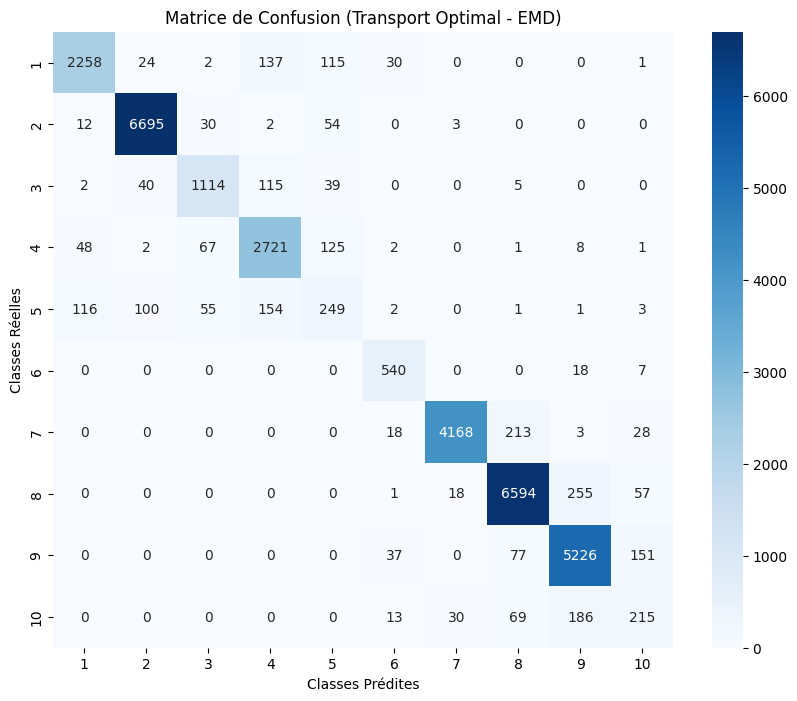

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage graphique de la matrice de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_emd, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title('Matrice de Confusion (Transport Optimal - EMD)')
plt.xlabel('Classes Prédites')
plt.ylabel('Classes Réelles')
plt.show()

On remarque  certaines erreurs se produisent régulièrement entre des classes spécifiques. Par exemple, une confusion assez marquée apparaît entre les classes 1 et 4, ainsi qu’entre les classes 1 et 5. Ces erreurs peuvent s'expliquer par une proximité structurelle entre ces classes dans l’espace des caractéristiques ou par un manque de discriminants clairs pour les différencier. En revanche, les classes 7 et 8 ont été particulièrement bien classées, ce qui montre que le modèle a réussi à identifier leurs caractéristiques distinctives.

Un autre point important concerne les classes minoritaires, notamment les classes 5 et 10. Le faible nombre d’observations dans ces catégories rend leur classification plus délicate et augmente les risques d’erreurs.

## **Partie II : Transport Optimal Régularisé et Algorithme de Sinkhorn**

Dans cette partie,nous utilisons le transport optimal régularisé pour résoudre le problème. L’objectif est de réduire le temps de calcul tout en garantissant une classification similaire ou meilleure à celle obtenue avec l’EMD (non régularisé).

L'algorithme dépend de plusieurs paramètres clés, et leur choix est crucial pour atteindre un compromis entre rapidité et précision.




### **Problème à résoudre**

Le problème peut être formulé comme suit :  
$P^*_\epsilon = \underset{P \in U(\alpha, \beta)}{\text{argmin}} \; \sum_{i,j} C_{ij} P_{ij} - \epsilon H(P),$

où :
- $P \in \mathbb{R}^{n \times m}$ est une matrice représentant les quantités transportées.  
- $C_{ij}$ est le coût associé au transport entre $X_i$ et $Y_j$.  
- $H(P) = -\sum_{i,j} P_{ij} (\log(P_{ij}) - 1)$ est l’entropie de $P$.  
- $\epsilon > 0$ est le paramètre de régularisation, contrôlant le lissage.  

L’ensemble des plans de transport admissibles $U(\alpha, \beta)$ est défini comme :  
$U(\alpha, \beta) = \{ P \; | \; \sum_j P_{ij} = a_i, \; \sum_i P_{ij} = b_j, \; P_{ij} \geq 0 \}.$

Ici, $a$ et $b$ sont respectivement les distributions de masse source et cible, avec :  
$a_i = \frac{1}{n}, \quad b_j = \frac{1}{m}.$

---

## **Algorithme de Sinkhorn**

L’algorithme de Sinkhorn résout le problème ci-dessus de manière itérative, en alternant les projections sur les contraintes des marginales.

### **Forme de la solution**

La solution optimale $P^*_\epsilon$ s’écrit :  
$P^*_\epsilon = \text{diag}(u^*) K^\epsilon \text{diag}(v^*),$

avec :
- $K^\epsilon_{ij} = e^{-\frac{C_{ij}}{\epsilon}}$, une matrice calculée à partir des coûts.  
- $u^*$ et $v^*$ sont des vecteurs de normalisation.

### **Itérations de Sinkhorn**

Les vecteurs $u$ et $v$ sont initialisés à des constantes normalisées, puis mis à jour comme suit :  
$u_{k+1} \leftarrow \frac{a}{K v_k}, \quad v_{k+1} \leftarrow \frac{b}{K^\top u_{k+1}}.$

Ces itérations convergent vers les valeurs $u^*$ et $v^*$, permettant de construire $P^*_\epsilon$.

---

## **Choix des Paramètres**

Les paramètres choisis dans l'algorithme de Sinkhorn sont les suivants :
- **Régularisation ($\epsilon = 4e-2$)** : Contrôle le lissage, garantissant un compromis entre rapidité et précision.  
- **Seuil d'arrêt ($\text{S_arret} = 1e-4$)** : Définit la précision des itérations.  
- **Nombre maximal d’itérations ($\text{numItermax} = 500$)** : Limite les calculs.

---

## **Résumé des Étapes**

1. Calcul de la matrice de coût $C$.  
2. Initialisation des vecteurs $u$ et $v$ (implémenter implicitement dans la fonction ot.sinkhorn).  
3. Itérations de Sinkhorn pour normaliser $P$.  
4. Calcul de $P^*_\epsilon$ et interprétation des résultats pour la classification et l’estimation des proportions.

Ces étapes seront implémentées dans la section suivante.



In [ ]:
# Matrice de coût avec la transformation logarithmique
C = cdist(X, Y, metric='sqeuclidean').astype(np.float32)
C = np.log1p(C)  # Transformation log(1 + C)

In [ ]:
# Mesures uniformes pour source et cible
a = np.ones(X.shape[0]) / X.shape[0]
b = np.ones(Y.shape[0]) / Y.shape[0]

# Paramètre de régularisation
epsilon =0.04  #parametre de regularisation
S_arret= 0.0001   #le critère d’arrêt.
numItermax = 500
# Calcul du plan de transport régularisé avec Sinkhorn
start_time = time.time()
P_star_sinkhorn = ot.sinkhorn(a, b, C, reg=epsilon, numItermax=numItermax,stopThr=S_arret)
end_time = time.time()

print(f"Total masse transportée (Sinkhorn) : {P_star_sinkhorn.sum():.6f}")
print(f"Temps d'exécution (Sinkhorn) : {end_time - start_time:.2f} secondes")


Total masse transportée (Sinkhorn) : 1.000000
Temps d'exécution (Sinkhorn) : 23.22 secondes


L'algorithme de Sinkhorn a convergé parfaitement avec une masse totale transportée de 1 et un temps d'exécution réduit (23,22s), démontrant son efficacité et sa stabilité numérique.

In [ ]:
Y_classes_sinkhorn = []

for j in range(P_star_sinkhorn.shape[1]):
    masses = P_star_sinkhorn[:, j]
    nonzero_indices = np.where(masses > 1e-10)[0]

    source_classes = X_clust[nonzero_indices]
    weights = masses[nonzero_indices]

    # Vote pondéré
    majority_class = np.bincount(source_classes, weights=weights).argmax()
    Y_classes_sinkhorn.append(majority_class)


In [ ]:
# Calcul des proportions des classes
class_counts_sinkhorn = Counter(Y_classes_sinkhorn)
proportions_sinkhorn = {k: v / len(Y_classes_sinkhorn) for k, v in class_counts_sinkhorn.items()}

print("Proportions des classes dans l'échantillon cible (Sinkhorn) :", proportions_sinkhorn)

# Évaluation des performances
accuracy_sinkhorn = accuracy_score(Y_clust, Y_classes_sinkhorn)
print(f"Exactitude de la classification (Sinkhorn) : {accuracy_sinkhorn * 100:.2f}%")

conf_matrix_sinkhorn = confusion_matrix(Y_clust, Y_classes_sinkhorn)
print("Matrice de confusion (Sinkhorn) :\n", conf_matrix_sinkhorn)


Proportions des classes dans l'échantillon cible (Sinkhorn) : {1: 0.08779217558435116, 2: 0.21985243970487942, 6: 0.01664703329406659, 4: 0.1030752061504123, 5: 0.001674003348006696, 7: 0.13782627565255132, 3: 0.03162006324012648, 8: 0.21535743071486144, 10: 0.002294004588009176, 9: 0.18386136772273545}
Exactitude de la classification (Sinkhorn) : 93.66%
Matrice de confusion (Sinkhorn) :
 [[2552    5    0    6    2    2    0    0    0    0]
 [   2 6784    0    0    9    0    1    0    0    0]
 [   0  151  968  182   12    0    0    2    0    0]
 [ 102    1    1 2863    4    1    0    0    2    1]
 [ 176  151   51  274   27    0    0    0    1    1]
 [   0    0    0    0    0  511    0    0   53    1]
 [   0    0    0    0    0    3 4316  104    1    6]
 [   0    0    0    0    0    0   78 6716  113   18]
 [   0    0    0    0    0    4    0   37 5439   11]
 [   0    0    0    0    0   16   51   88  322   36]]


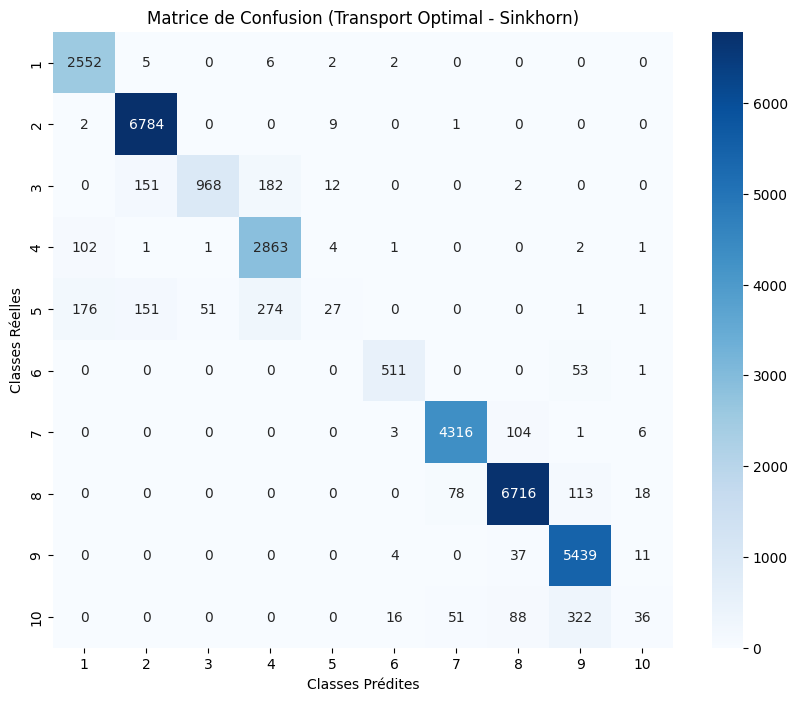

In [ ]:
# Affichage graphique de la matrice de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_sinkhorn, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title('Matrice de Confusion (Transport Optimal - Sinkhorn)')
plt.xlabel('Classes Prédites')
plt.ylabel('Classes Réelles')
plt.show()

L'algorithme de Sinkhorn a atteint une exactitude globale de 93,66 %, indiquant une classification précise et fiable des points cibles. Les proportions des classes prédites sont cohérentes avec les attentes, avec une dominance des classes 2 (21,98 %), 8 (21,53 %) et 9 (18,39 %), tandis que les classes 5 (0,17 %) et 10 (0,23 %) restent minoritaires.

La matrice de confusion montre une répartition globalement correcte, avec des erreurs de classification principalement observées entre les classes 2 ↔ 3 et 4 ↔ 5, ce qui pourrait s'expliquer par une proximité structurelle dans l'espace des caractéristiques.
Les classes 7, 8, et 9 ont des prédictions globalement très précises avec très peu d'erreurs.

## 📊 **Partie III : Comparaison avec le Vrai Clustering et Impact de la Régularisation**

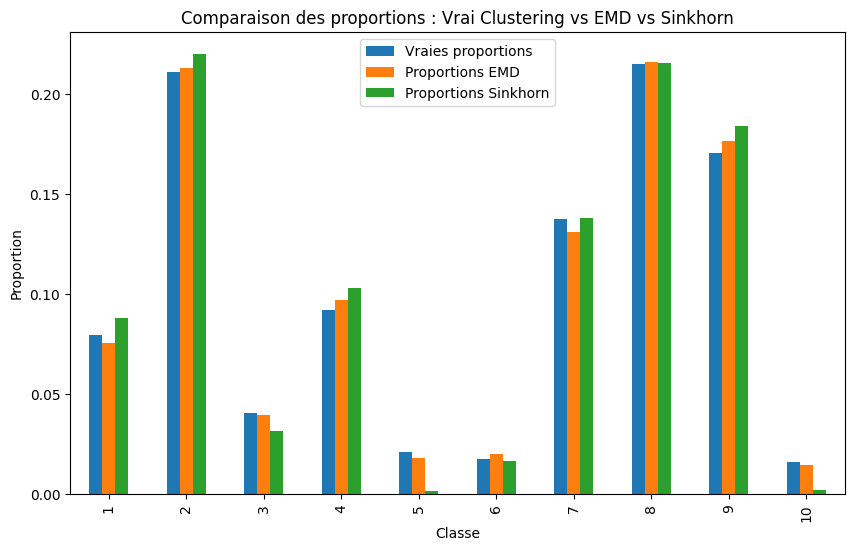

In [ ]:
# Vraies proportions
true_proportions = pd.Series(Y_clust).value_counts(normalize=True).sort_index()

# Comparaison avec les proportions obtenues
proportions_comparison = pd.DataFrame({
    "Classe": true_proportions.index,
    "Vraies proportions": true_proportions.values,
    "Proportions EMD": [proportions_emd.get(k, 0) for k in true_proportions.index],
    "Proportions Sinkhorn": [proportions_sinkhorn.get(k, 0) for k in true_proportions.index]
})

# Affichage
proportions_comparison.plot(x="Classe", kind="bar", figsize=(10, 6), title="Comparaison des proportions : Vrai Clustering vs EMD vs Sinkhorn")
plt.xlabel('Classe')
plt.ylabel('Proportion')
plt.show()


### **Comparaison des Proportions des Classes**

En comparant les proportions des classes issues du **vrai clustering**, de l'approche **EMD**, et de l'approche **Sinkhorn**, voici les principales observations :

- Les proportions obtenues par les deux méthodes (**EMD** et **Sinkhorn**) sont globalement proches des vraies proportions.  
- L'algorithme **EMD** est légèrement plus fidèle pour certaines classes minoritaires (**5** et **10**), tandis que **Sinkhorn** capture mieux certaines classes dominantes (**2**, **4**).  
- Les différences restent faibles, ce qui confirme que la régularisation introduite par **Sinkhorn** n'a pas perturbé la répartition globale des classes.

- On remarque une bonne stabilité des deux méthodes par rapport aux vraies proportions, avec des écarts faibles sur certaines classes spécifiques.

---

### **Comparaison des Précisions**

- **Exactitude (EMD) :** **92,32 %**  
- **Exactitude (Sinkhorn) :** **93,66 %**

L'algorithme **Sinkhorn** a obtenu une **légère amélioration de la precision** par rapport à **EMD**, ce qui indique que la régularisation a permis d'affiner certaines prédictions sans perte significative de précision.

---

### **Analyse des Matrices de Confusion**

- Les matrices de confusion montrent que les erreurs de classification se concentrent principalement entre les classes **2 ↔ 3** et **4 ↔ 5** pour les deux méthodes.  
- **Sinkhorn** a légèrement réduit certaines confusions par rapport à **EMD**, notamment pour les classes **1**, **4**, et **8**.  
- Cependant, les deux méthodes restent cohérentes et efficaces dans la majorité des classes.

- Les erreurs sont similaires entre les deux approches, mais **Sinkhorn** offre une meilleure précision pour certaines classes dominantes.

---

### **Impact de la Régularisation**

- **Temps de calcul :**
   - **EMD :** Temps plus long en raison de l'absence de régularisation.  
   - **Sinkhorn :** Temps significativement réduit (**23,22 secondes**) grâce à la stabilisation numérique apportée par le paramètre de régularisation.  

- **Stabilité des prédictions :**
   - Sinkhorn montre une meilleure stabilité et une convergence plus rapide que l'approche EMD.

- **Qualité des prédictions :**
   - L'amélioration de l'exactitude par Sinkhorn est marginale, mais notable.  
   - Certaines classes sont mieux capturées avec Sinkhorn, notamment les classes dominantes.

---

### **Conclusion**

- Les deux méthodes, **EMD** et **Sinkhorn**, donnent des résultats **globalement cohérents** et **proches du vrai clustering**.  
- **Sinkhorn** se distingue par :  
   - Un **temps de calcul réduit**,  
   - Une **meilleure stabilité**,  
   - Une **légère amélioration de l'exactitude**.  

- Pour des jeux de données volumineux ou nécessitant des itérations fréquentes, **Sinkhorn** semble être un **choix optimal** en raison de son efficacité numérique.

---
